In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import matplotlib.patches as patches

import ipywidgets as widgets
from IPython.display import display
import trimesh
from torch import autograd as Grad
import random
import math



In [2]:

def local_parametrisation(t, mesh_path, n):

    tm = trimesh.load(mesh_path)
    V = torch.tensor(tm.vertices, dtype=torch.float)  # Ensure V is a tensor

    

    coarse_indices = [ int( j * (V.shape[0] - 1) / n) for j in range(n) ]
    
    coarse_points = V[coarse_indices,:2]

    out = torch.zeros(t.shape[0], n, 2)
    for j in range(n):
        if j==n-1:
            i = coarse_indices[n-1] + t*(V.shape[0] - coarse_indices[n-1])
        else:
            i = coarse_indices[j] + t*(coarse_indices[(j+1)%n] - coarse_indices[j])

        s, i = torch.frac(i), torch.floor(i).long()  # Use torch.frac() for fractional part
    
        out[:,j,:] = V[i, :2].squeeze() * (1 - s) + V[(i+1)%V.shape[0], :2].squeeze() * s


    return out, coarse_points



def blend_func_simple(x):

    result = torch.zeros_like(x)  
    mask = torch.abs(x) < 1
    result[mask] = torch.exp(1 + (1 / (x[mask]**2 - 1)))
    
    return result

def blend_func(x,v=0.5):

    result = torch.zeros_like(x)  
    mask = torch.abs(x) < (1+v)/2
    temp = (1+v)**2
    result[mask] = torch.exp(1 + (temp / (4*x[mask]**2 - temp)))
    
    return result

def pou_blend_func(x, v=0.5):
    
    result = torch.zeros_like(x)
    mask = torch.abs(x) < (1+v)/2
    b = blend_func(x,v=v)
    b_minus = blend_func(1-abs(x), v=v )

    result[mask] = ( b / (b+b_minus))[mask]

    return result



def gradient( out, wrt, allow_unused=False):

		B = 1 if len(out.size()) < 3 else out.size(0)
		N = out.size(0) if len(out.size()) < 3 else out.size(1)
		R = out.size(-1)
		C = wrt.size(-1)

		gradients = []
		for dim in range(R):
			out_p = out[..., dim].flatten()

			select = torch.ones(out_p.size(), dtype=torch.float32).to(out.device)

			gradient = Grad.grad(outputs=out_p, inputs=wrt, grad_outputs=select, create_graph=True, allow_unused=allow_unused)[0]
			gradients.append(gradient)

		if len(out.size()) < 3:
			J_f_uv = torch.cat(gradients, dim=1).view(N, R, C)
		else:
			J_f_uv = torch.cat(gradients, dim=2).view(B, N, R, C)

		return J_f_uv




class MLP(nn.Module):
	def __init__(self, layer_sizes):
		super(MLP, self).__init__()
		layers = []
		for i in range(len(layer_sizes) - 1):
			layers.append(nn.Linear(layer_sizes[i], layer_sizes[i + 1]))
			if i < len(layer_sizes) - 2:  # No activation on last layer
				layers.append(nn.Tanh())
		self.network = nn.Sequential(*layers)

        
	
	def forward(self, x):
		return self.network(x)

class BlendedMLP(nn.Module):
    def __init__(self, n, layer_sizes, coarse_points):
        super(BlendedMLP, self).__init__()
        self.mlps = nn.ModuleList([MLP(layer_sizes) for _ in range(n)])
        self.coarse_points = coarse_points
        self.n = n
        self.weights = [1 for i in range(n)]
        
        #self.rotations = [torch.eye(2) for i in range(n)]
        self.compute_fixed_rotations_and_scales()

        self.default_coarse_points = self.coarse_points
        self.default_rotations = self.rotations
        self.default_scales = self.scales

        
        self.fake_mlps = [lambda x: (torch.rand(1) + torch.sin(5*x)+2)*torch.stack([torch.cos(x), torch.sin(x)]).squeeze().transpose(0,1) for _ in range(n)]

    def reset(self):
        self.rotations = self.default_rotations
        self.scales = self.default_scales
        self.coarse_points = self.default_coarse_points
        self.weights = [1 for i in range(n)]

    def compute_fixed_rotations_and_scales(self):
        self.rotations = []
        self.scales = []
        for i in range(self.n):
            vec0 = self.coarse_points[i, :] - self.coarse_points[(i-1)%self.n, :]
            length0 = torch.sqrt((vec0*vec0).sum(-1))
            vec0 = vec0 / length0
            
            vec1 = self.coarse_points[(i+1)%self.n, :] - self.coarse_points[i, :]
            length1 = torch.sqrt((vec1*vec1).sum(-1))
            vec1 = vec1 / length1

            vec = (vec0+vec1)/2

            R = torch.tensor ([[vec[0], -1*vec[1] ],
                              [vec[1], vec[0] ] ]).transpose(1,0)

            self.rotations.append(R)

            s = length0+length1

            self.scales.append(s)

    



    def save_mlps(self, filename="mlps.pth"):
        torch.save({
            'mlps_state_dict': [mlp.state_dict() for mlp in self.mlps],
        }, filename)
    
    def load_mlps(self, filename="mlps.pth"):
        checkpoint = torch.load(filename)
        
        for mlp, state_dict in zip(self.mlps, checkpoint['mlps_state_dict']):
            mlp.load_state_dict(state_dict)

            
    def component(self, x, i):
        
        return (self.weights[i] * self.scales[i] * self.mlps[i](x)@self.rotations[i]  + self.coarse_points[i] ) 
        
       
    def forward(self, x):
        return torch.stack([ ( self.component(x,i)* pou_blend_func(x) +
                              self.component(x+1,(i-1)%self.n)* pou_blend_func(x+1) +
                              self.component(x-1, (i+1)%self.n )* pou_blend_func(x-1) ) for i in range(self.n) ]).transpose(1,0)



    def diff_quants(self, x, i):
        x.requires_grad = True  # Enable differentiation
        r = self.forward(x)[:, i, :]  # Compute function output
        
        # Compute gradient of r w.r.t x
        tangent = gradient(out=r, wrt=x).squeeze()
    
    
        # Compute normalized tangent (unit vector)
        speed = torch.norm(tangent, dim=1, keepdim=True)
        
        unit_tangent = tangent / speed

        R = torch.tensor([[0.0,1.0,],
                          [-1.0,0.0]])
        
        unit_normal = unit_tangent @ R

        # Compute normal: derivative of tangent w.r.t x
        unit_tangent_deriv = gradient(out=unit_tangent, wrt=x).squeeze()

        print(unit_tangent_deriv.shape,  unit_normal.shape)

        norms = torch.norm(unit_tangent_deriv, dim=1, keepdim=True)

        k = torch.sign((unit_tangent_deriv * unit_normal).sum(-1)) * norms.squeeze() / speed.squeeze()


        
       
        
        return r, unit_tangent, unit_normal, k

        

        


        

'''
x = torch.arange(-2,2,0.01)
y=blend_func(x)
plt.plot(x,y)
plt.show()
'''


'\nx = torch.arange(-2,2,0.01)\ny=blend_func(x)\nplt.plot(x,y)\nplt.show()\n'

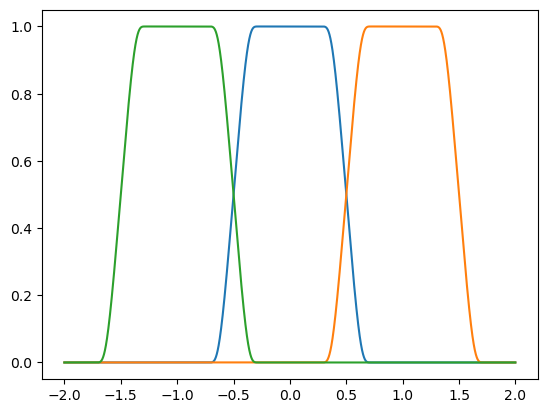

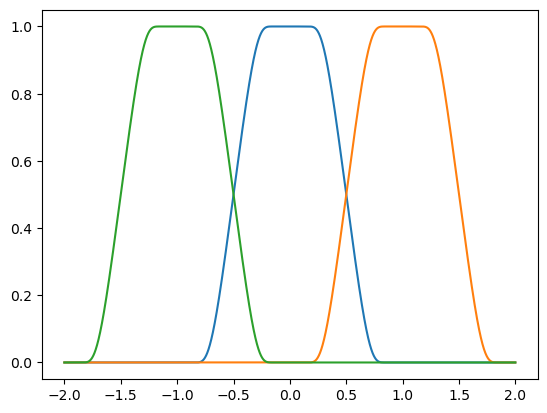

In [10]:

from bns_utils import B2_inv_exp as blend_func


t = torch.arange(-2,2,0.001)
plt.plot(t, blend_func(abs(t), v=0.5))
plt.plot(t, blend_func(abs(t-1), v=0.5))
plt.plot(t, blend_func(abs(t+1), v=0.5))

plt.savefig('blend_func_v=05.pdf')
plt.show()


t = torch.arange(-2,2,0.001)
plt.plot(t, blend_func(abs(t), v=0.8))
plt.plot(t, blend_func(abs(t-1), v=0.8))
plt.plot(t, blend_func(abs(t+1), v=0.8))

plt.savefig('blend_func_v=08.pdf')
plt.show()





In [4]:

def update_plot( **slider_values ):
    t =  torch.arange(-1, 1.01, 0.01).unsqueeze(-1)

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # Extract weights from slider values
    blended_mlp.weights = [slider_values[f'weight_{i}'] for i in range(blended_mlp.n)]

    current_t = torch.tensor(slider_values['t slider']).unsqueeze(0)


    components = [blended_mlp.component(t,i) for i in range(blended_mlp.n)]
    
    output = blended_mlp(0.5*t)
    current_output=blended_mlp(current_t).transpose(0,1)
    current_component_part = [blended_mlp.component(current_t,i) for i in range(blended_mlp.n)]

    #print('cur output', current_output.shape)

    #blend_weight = blend_func(t)
    target, _ = local_parametrisation(torch.arange(0,1.0, 0.01).unsqueeze(-1), mesh_path = mesh_path, n=n)
    
    #print(output.shape)
   
    
    axes[0].set_xlim([-1.2, 1.2])
    axes[0].set_ylim([-1.2, 1.2])
    axes[0].set_title("Components")

    colors = [plt.get_cmap("tab10")(i % 10) for i in range(blended_mlp.n)]
    for i in range(blended_mlp.n):
        #output = torch.tensor(output)
        #print(output)
        color=colors[i]
        axes[0].plot(components[i][:,0].detach(), components[i][:,1].detach(), linewidth=1, alpha=0.9, label=str(i), color=color)

        axes[0].scatter(current_component_part[i][0].detach(), current_component_part[i][1].detach(), linewidth=1, alpha=0.5, s=10, color=color)

        
        axes[0].plot(output.detach()[:,i, 0], output.detach()[:,i, 1], color='blue', linewidth=1, alpha=0.1)


        axes[1].plot(output.detach()[:, i, 0], output.detach()[ :,i, 1], linewidth=1, alpha=1, linestyle='-', color=color, label=str(i))
        axes[1].plot(target.detach()[:,i,0], target.detach()[:,i,1], color='red', alpha=0.2, linestyle=':')
    
        axes[1].scatter(blended_mlp.coarse_points[i,0], blended_mlp.coarse_points[i,1], alpha=0.5, color=color, marker='x')

        axes[1].scatter(current_output.detach()[i,0], current_output.detach()[i,1], color=color, alpha=0.5)

    axes[0].plot([],[], color='blue', linewidth=1, alpha=0.1, label='combined')

        
    axes[0].legend()
    axes[1].legend()


    
    axes[1].set_title("Combined Shape")
    axes[1].set_xlim([-1.2, 1.2])
    axes[1].set_ylim([-1.2, 1.2])

    plt.show()


def show():
    # Generate sliders for each weight
    sliders = {
        f'weight_{i}': widgets.FloatSlider(min=0, max=1, step=0.1, value=1, description=f"W{i}") for i in range(blended_mlp.n)
    }
    sliders['t slider'] = widgets.FloatSlider(min=-1, max=1, step=0.01, value=0, description='t slider')
    
    # Create interactive widget with all sliders
    interactive_plot = widgets.interactive(update_plot, **sliders)
    
    # Display sliders and plot
    display(interactive_plot)




def update_diff_quant_plot(t_slider, r, unit_tangent, unit_normal, k, all_t):
    t = t_slider

    # Convert PyTorch tensors to NumPy (if they are not already)
    r_np = r.detach().cpu().numpy()
    unit_normal_np = unit_normal.detach().cpu().numpy()

    # Create figure and axis
    fig, ax = plt.subplots()

    # Extract components for quiver plot
    U = unit_normal_np[::10, 0]  # x-component
    V = unit_normal_np[::10, 1]  # y-component

    # Plot normals using quiver
    ax.quiver(
        r_np[::10, 0], r_np[::10, 1], U, V, 
        angles='xy', scale_units='xy', scale=50, 
        color='b', alpha=0.2, label='Normals',
        headwidth=0, headlength=0, headaxislength=0
    )

    ax.set_aspect('equal')

    # Plot the main curve
    ax.plot(r_np[:, 0], r_np[:, 1], color='black', linewidth=0.5, alpha=0.2)




    radii = 1/torch.abs(k).detach()
    circle_centres = r.detach() + torch.sign(k).unsqueeze(-1) * radii.unsqueeze(-1) * unit_normal.detach() 

    #print('all t shape', all_t.shape)
    t_index = ((t+1)/2) * (all_t.shape[0]-1)

    #print(t_index, int(t_index))
    t_index=round(t_index)

    #print(all_t[t_index,:])
    radius = radii[t_index]
    (x,y) = circle_centres[t_index,:]

    xlim = ax.get_xlim()
    ylim=ax.get_ylim()

    circle = patches.Circle((x, y), radius, fill=False, linewidth=1, alpha=0.8, color='black')
    ax.scatter(r.detach()[t_index,0], r.detach()[t_index,1], marker='x', color='black')
    ax.add_patch(circle)  # Use ax.add_patch() instead of plt.add_patch()
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)


    

    plt.show()

def show_diff_quant(i=0):
    # Create slider widget
    t_slider = widgets.FloatSlider(min=-1, max=1, step=0.001, value=0, description='t slider')

    # Generate differential quantities (assuming `blended_mlp.diff_quants` is correct)
    all_t = torch.arange(-1, 1.001, 0.001).unsqueeze(-1)

    #print(all_t)
    r, unit_tangent, unit_normal, k = blended_mlp.diff_quants(all_t, i=i)


    # Create interactive plot
    interactive_plot = widgets.interactive(
        update_diff_quant_plot, 
        t_slider=t_slider, 
        r=widgets.fixed(r), 
        unit_tangent=widgets.fixed(unit_tangent), 
        unit_normal=widgets.fixed(unit_normal), 
        k=widgets.fixed(k),
        all_t=widgets.fixed(all_t)
    )

    display(interactive_plot)





def update_deform_plot( **slider_values ):
    t =  torch.arange(-1, 1.01, 0.01).unsqueeze(-1)

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # Extract weights from slider values
    #blended_mlp.weights = [slider_values[f'weight_{i}'] for i in range(blended_mlp.n)]
    pos = torch.stack([ torch.tensor([slider_values[f'x_disp_{i}'], slider_values[f'y_disp_{i}'] ]) 
                       for i in range(blended_mlp.n)])
    
    blended_mlp.coarse_points = pos
    blended_mlp.compute_fixed_rotations_and_scales()

    


    components = [blended_mlp.component(t,i) for i in range(blended_mlp.n)]
    
    output = blended_mlp(0.5*t)
    

    #print('cur output', current_output.shape)

    #blend_weight = blend_func(t)
    target, _ = local_parametrisation(torch.arange(0,1.0, 0.01).unsqueeze(-1), mesh_path = mesh_path, n=n)
    
    #print(output.shape)
   
    
    axes[0].set_xlim([-1.2, 1.2])
    axes[0].set_ylim([-1.2, 1.2])
    axes[0].set_title("Components")

    colors = [plt.get_cmap("tab10")(i % 10) for i in range(blended_mlp.n)]
    for i in range(blended_mlp.n):
        #output = torch.tensor(output)
        #print(output)
        color=colors[i]
        axes[0].plot(components[i][:,0].detach(), components[i][:,1].detach(), linewidth=1, alpha=0.9, label=str(i), color=color)

        
        
        axes[0].plot(output.detach()[:,i, 0], output.detach()[:,i, 1], color='blue', linewidth=1, alpha=0.1)


        axes[1].plot(output.detach()[:, i, 0], output.detach()[ :,i, 1], linewidth=1, alpha=1, linestyle='-', color=color, label=str(i))
        axes[1].plot(target.detach()[:,i,0], target.detach()[:,i,1], color='red', alpha=0.2, linestyle=':')
    
        axes[1].scatter(blended_mlp.coarse_points[i,0], blended_mlp.coarse_points[i,1], alpha=0.5, color=color, marker='x')

        
    axes[0].plot([],[], color='blue', linewidth=1, alpha=0.1, label='combined')

        
    axes[0].legend()
    axes[1].legend()


    
    axes[1].set_title("Combined Shape")
    axes[1].set_xlim([-1.2, 1.2])
    axes[1].set_ylim([-1.2, 1.2])

    plt.show()


def show_deform():
   
    sliders = {
        **{f'x_disp_{i}': widgets.FloatSlider(min=-1, max=1, step=0.001, value=blended_mlp.coarse_points[i,0], description=f"x_disp_{i}") for i in range(blended_mlp.n)},
        **{f'y_disp_{i}': widgets.FloatSlider(min=-1, max=1, step=0.001, value=blended_mlp.coarse_points[i,1], description=f"y_disp_{i}") for i in range(blended_mlp.n)}
    }

    
    # Create interactive widget with all sliders
    interactive_plot = widgets.interactive(update_deform_plot, **sliders)
    
    # Display sliders and plot
    display(interactive_plot)





















In [5]:
'''



import matplotlib.pyplot as plt
import torch
import ipywidgets as widgets
from IPython.display import display, clear_output

# Create the plot as a separate function so we can reuse it
def create_plot(slider_values):
    t = torch.arange(-1, 1.01, 0.01).unsqueeze(-1)
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # Extract weights from sliders
    blended_mlp.weights = [slider_values[f'weight_{i}'] for i in range(blended_mlp.n)]
    current_t = torch.tensor(slider_values['t slider']).unsqueeze(0)

    components = [blended_mlp.component(t, i) for i in range(blended_mlp.n)]
    output = blended_mlp(0.5 * t)
    current_output = blended_mlp(current_t).transpose(0, 1)
    current_component_part = [blended_mlp.component(current_t, i) for i in range(blended_mlp.n)]

    target, _ = local_parametrisation(torch.arange(0, 1.0, 0.01).unsqueeze(-1), mesh_path=mesh_path, n=n)

    colors = [plt.get_cmap("tab10")(i % 10) for i in range(blended_mlp.n)]

    axes[0].set_xlim([-1.2, 1.2])
    axes[0].set_ylim([-1.2, 1.2])
    axes[0].set_title("Components")

    for i in range(blended_mlp.n):
        color = colors[i]
        axes[0].plot(components[i][:, 0].detach(), components[i][:, 1].detach(), linewidth=1, alpha=0.9, label=str(i), color=color)
        axes[0].scatter(current_component_part[i][0].detach(), current_component_part[i][1].detach(), s=10, alpha=0.5, color=color)
        axes[0].plot(output.detach()[:, i, 0], output.detach()[:, i, 1], color='blue', linewidth=1, alpha=0.1)

        axes[1].plot(output.detach()[:, i, 0], output.detach()[:, i, 1], linewidth=1, alpha=1, linestyle='-', color=color, label=str(i))
        axes[1].plot(target.detach()[:, i, 0], target.detach()[:, i, 1], color='red', alpha=0.2, linestyle=':')
        axes[1].scatter(blended_mlp.coarse_points[i, 0], blended_mlp.coarse_points[i, 1], alpha=0.5, color=color, marker='x')
        axes[1].scatter(current_output.detach()[i, 0], current_output.detach()[i, 1], color=color, alpha=0.5)

    axes[0].plot([], [], color='blue', linewidth=1, alpha=0.1, label='combined')
    axes[0].legend()
    axes[1].legend()
    axes[1].set_title("Combined Shape")
    axes[1].set_xlim([-1.2, 1.2])
    axes[1].set_ylim([-1.2, 1.2])

    return fig


# Stores the latest slider values
latest_slider_values = {}

def update_plot(**slider_values):
    global latest_slider_values
    latest_slider_values = slider_values  # Save for export
    fig = create_plot(slider_values)
    plt.show()


def save_plot(_):
    if latest_slider_values:
        fig = create_plot(latest_slider_values)
        fig.savefig("output_plot.pdf", format="pdf")
        plt.close(fig)
        print("Plot saved as output_plot.pdf")


def show():
    # Sliders
    sliders = {
        f'weight_{i}': widgets.FloatSlider(min=0, max=1, step=0.1, value=1, description=f"W{i}") for i in range(blended_mlp.n)
    }
    sliders['t slider'] = widgets.FloatSlider(min=-1, max=1, step=0.01, value=0, description='t slider')

    # Save Button
    save_button = widgets.Button(description="Save as PDF", button_style='success')
    save_button.on_click(save_plot)

    # Interactive display
    interactive_plot = widgets.interactive(update_plot, **sliders)
    display(widgets.VBox([interactive_plot, save_button]))

'''

'\n\n\n\nimport matplotlib.pyplot as plt\nimport torch\nimport ipywidgets as widgets\nfrom IPython.display import display, clear_output\n\n# Create the plot as a separate function so we can reuse it\ndef create_plot(slider_values):\n    t = torch.arange(-1, 1.01, 0.01).unsqueeze(-1)\n    fig, axes = plt.subplots(1, 2, figsize=(12, 5))\n\n    # Extract weights from sliders\n    blended_mlp.weights = [slider_values[f\'weight_{i}\'] for i in range(blended_mlp.n)]\n    current_t = torch.tensor(slider_values[\'t slider\']).unsqueeze(0)\n\n    components = [blended_mlp.component(t, i) for i in range(blended_mlp.n)]\n    output = blended_mlp(0.5 * t)\n    current_output = blended_mlp(current_t).transpose(0, 1)\n    current_component_part = [blended_mlp.component(current_t, i) for i in range(blended_mlp.n)]\n\n    target, _ = local_parametrisation(torch.arange(0, 1.0, 0.01).unsqueeze(-1), mesh_path=mesh_path, n=n)\n\n    colors = [plt.get_cmap("tab10")(i % 10) for i in range(blended_mlp.n)]\n\

In [6]:
n=6
layer_sizes = [1, 16, 16, 2]
mesh_path = "data/curves/eagle_bdry.obj"

t_train = torch.arange(0,1.0, 0.01).unsqueeze(-1)
target_train, coarse_points = local_parametrisation(t_train, mesh_path = mesh_path, n=n)
    

blended_mlp = BlendedMLP(n, layer_sizes, coarse_points)



# Training all models jointly
optimizer = optim.Adam(blended_mlp.parameters(), lr=0.01)
criterion = nn.MSELoss()







In [7]:
blended_mlp.reset()
show();

interactive(children=(FloatSlider(value=1.0, description='W0', max=1.0), FloatSlider(value=1.0, description='W…

In [9]:
for i in range(blended_mlp.n):
    show_diff_quant(i=i);

torch.Size([2001, 2]) torch.Size([2001, 2])


interactive(children=(FloatSlider(value=0.0, description='t slider', max=1.0, min=-1.0, step=0.001), Output())…

torch.Size([2001, 2]) torch.Size([2001, 2])


interactive(children=(FloatSlider(value=0.0, description='t slider', max=1.0, min=-1.0, step=0.001), Output())…

torch.Size([2001, 2]) torch.Size([2001, 2])


...

interactive(children=(FloatSlider(value=0.0, description='t slider', max=1.0, min=-1.0, step=0.001), Output())…

torch.Size([2001, 2]) torch.Size([2001, 2])


interactive(children=(FloatSlider(value=0.0, description='t slider', max=1.0, min=-1.0, step=0.001), Output())…

torch.Size([2001, 2]) torch.Size([2001, 2])


interactive(children=(FloatSlider(value=0.0, description='t slider', max=1.0, min=-1.0, step=0.001), Output())…

In [20]:
epoch=0

In [21]:

optimizer = optim.Adam(blended_mlp.parameters(), lr=0.001)
# Training loop
for _ in range(100000):
    optimizer.zero_grad()
    output_train = blended_mlp(t_train)
    #loss = criterion(output_train, target_train)
    #print(output_train.shape)
    #print(target_train.shape)
    loss = (output_train-target_train).pow(2).mean()
    loss.backward()
    optimizer.step()

    # Corrected indentation for if condition
    if epoch % 100 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item():.6f}")
    
    epoch += 1  # Increment epoch counter


Epoch 0, Loss: 0.065456
Epoch 100, Loss: 0.003554
Epoch 200, Loss: 0.003293
Epoch 300, Loss: 0.003178
Epoch 400, Loss: 0.003056
Epoch 500, Loss: 0.002928
Epoch 600, Loss: 0.002809
Epoch 700, Loss: 0.002708
Epoch 800, Loss: 0.002613
Epoch 900, Loss: 0.002531
Epoch 1000, Loss: 0.002473
Epoch 1100, Loss: 0.002428
Epoch 1200, Loss: 0.002383
Epoch 1300, Loss: 0.002333
Epoch 1400, Loss: 0.002275
Epoch 1500, Loss: 0.002213
Epoch 1600, Loss: 0.002145
Epoch 1700, Loss: 0.002071
Epoch 1800, Loss: 0.001994
Epoch 1900, Loss: 0.001920
Epoch 2000, Loss: 0.001848
Epoch 2100, Loss: 0.001775
Epoch 2200, Loss: 0.001698
Epoch 2300, Loss: 0.001618
Epoch 2400, Loss: 0.001530
Epoch 2500, Loss: 0.001432
Epoch 2600, Loss: 0.001345
Epoch 2700, Loss: 0.001288
Epoch 2800, Loss: 0.001256
Epoch 2900, Loss: 0.001237
Epoch 3000, Loss: 0.001224
Epoch 3100, Loss: 0.001212
Epoch 3200, Loss: 0.001202
Epoch 3300, Loss: 0.001191
Epoch 3400, Loss: 0.001181
Epoch 3500, Loss: 0.001172
Epoch 3600, Loss: 0.001163
Epoch 3700, L


KeyboardInterrupt



In [12]:
#blended_mlp.save_mlps('models/eagle6.pth')
#blended_mlp.load_mlps('models/eagle6.pth')

In [22]:
blended_mlp.reset()
show()

interactive(children=(FloatSlider(value=1.0, description='W0', max=1.0), FloatSlider(value=1.0, description='W…

In [23]:
############# Rotation Equivariance ############
blended_mlp.reset()
R = torch.tensor([[0.0, 1.0],
                  [-1.0, 0.0]])

blended_mlp.coarse_points = blended_mlp.coarse_points @ R

blended_mlp.compute_fixed_rotations_and_scales()


show()

interactive(children=(FloatSlider(value=1.0, description='W0', max=1.0), FloatSlider(value=1.0, description='W…

In [24]:
############# Translation Equivariance ############
blended_mlp.reset()
T = torch.tensor([-0.5, +0.3 ])

blended_mlp.coarse_points = blended_mlp.coarse_points + T

blended_mlp.compute_fixed_rotations_and_scales()

show()

interactive(children=(FloatSlider(value=1.0, description='W0', max=1.0), FloatSlider(value=1.0, description='W…

In [25]:
############# Scale Equivariance ############
blended_mlp.reset()
s = 0.5

blended_mlp.coarse_points = blended_mlp.coarse_points * s

blended_mlp.compute_fixed_rotations_and_scales()


show()

interactive(children=(FloatSlider(value=1.0, description='W0', max=1.0), FloatSlider(value=1.0, description='W…

In [26]:
############# Translating a Single Coarse Vertex ############
blended_mlp.reset()
T = torch.zeros_like(blended_mlp.coarse_points)
T[0,:] = torch.tensor([-0.1, +0.1 ])

blended_mlp.coarse_points = blended_mlp.coarse_points + T

blended_mlp.compute_fixed_rotations_and_scales()

show()

interactive(children=(FloatSlider(value=1.0, description='W0', max=1.0), FloatSlider(value=1.0, description='W…

In [27]:
blended_mlp.reset()
show_deform()

interactive(children=(FloatSlider(value=-0.7891812324523926, description='x_disp_0', max=1.0, min=-1.0, step=0…

In [28]:
for i in range(blended_mlp.n):
    show_diff_quant(i=i);

torch.Size([2001, 2]) torch.Size([2001, 2])


interactive(children=(FloatSlider(value=0.0, description='t slider', max=1.0, min=-1.0, step=0.001), Output())…

torch.Size([2001, 2]) torch.Size([2001, 2])


interactive(children=(FloatSlider(value=0.0, description='t slider', max=1.0, min=-1.0, step=0.001), Output())…

torch.Size([2001, 2]) torch.Size([2001, 2])


...

interactive(children=(FloatSlider(value=0.0, description='t slider', max=1.0, min=-1.0, step=0.001), Output())…

torch.Size([2001, 2]) torch.Size([2001, 2])


interactive(children=(FloatSlider(value=0.0, description='t slider', max=1.0, min=-1.0, step=0.001), Output())…

torch.Size([2001, 2]) torch.Size([2001, 2])


interactive(children=(FloatSlider(value=0.0, description='t slider', max=1.0, min=-1.0, step=0.001), Output())…